# 07 - Uncertainty Quantification: Bootstrap 95% CIs on Held-Out Metrics

Point estimates of classifier performance look authoritative but hide sampling variability.
TRIPOD+AI (2024) guidance for clinical prediction models requires confidence intervals on
held-out metrics. This notebook computes:

1. **2000-resample non-parametric bootstrap** percentile 95% CIs (2.5%, 97.5%), point
   estimate, and standard error for ROC-AUC, recall (sensitivity), specificity, PPV
   (precision), NPV, F1, and F2 at each model's stored decision threshold.
2. **Paired bootstrap test** for ΔAUC = AUC_enhanced − AUC_screening on the matched
   holdout rows, with a two-sided empirical p-value.
3. A histogram overlay of the bootstrap AUC distributions for the two models.

The holdout split is reproduced with `random_state=42, test_size=0.25, stratify=y`, which
matches the rows the model was originally evaluated on (verified against the stored
`metrics` block of each artifact).


In [1]:
from pathlib import Path
import json, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             f1_score, fbeta_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
N_BOOT = 2000
TARGET = "pcos_y_n"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "outputs" / "pcos_cleaned.csv"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
for d in (METRICS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Data:", DATA_PATH)
print("Models dir:", MODELS_DIR)


Data: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\pcos_cleaned.csv
Models dir: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\models


## Load Data and Trained Artifacts

Each artifact is a dict with keys `model` (sklearn Pipeline), `features`, `threshold`,
and a stored `metrics` block. We sanity-check that the reproduced holdout AUC matches the
stored value before running any bootstrap, so the resampling is operating on the same
rows the model was originally evaluated on.


In [2]:
pcos = pd.read_csv(DATA_PATH)
y = pcos[TARGET].astype(int)
print("Dataset shape:", pcos.shape, "| positives:", int(y.sum()))

screening_artifact = joblib.load(MODELS_DIR / "pcos_screening_model.joblib")
enhanced_artifact = joblib.load(MODELS_DIR / "pcos_enhanced_model.joblib")

artifacts = {
    "screening": screening_artifact,
    "enhanced": enhanced_artifact,
}
for name, art in artifacts.items():
    print(f"{name}: threshold={art['threshold']}, n_features={len(art['features'])}, "
          f"stored AUC={art['metrics']['roc_auc']:.4f}")


Dataset shape: (541, 41) | positives: 177


screening: threshold=0.285, n_features=13, stored AUC=0.8955
enhanced: threshold=0.38, n_features=27, stored AUC=0.9528


## Reproduce the Held-Out Predictions

Both models were trained with the same target `y` and the same `train_test_split` keyword
arguments. Because `stratify=y` and `random_state=42` are identical, the row indices of
the held-out split are identical across the two models — which is what we need for a
*paired* bootstrap on ΔAUC.


In [3]:
def holdout_predictions(artifact, X_all, y_all):
    """Reproduce the holdout split for an artifact and return (y_test, proba, threshold, test_index)."""
    X = X_all[artifact["features"]].copy()
    _, X_test, _, y_test = train_test_split(
        X, y_all, test_size=0.25, stratify=y_all, random_state=RANDOM_STATE,
    )
    proba = artifact["model"].predict_proba(X_test)[:, 1]
    return y_test.reset_index(drop=True), proba, float(artifact["threshold"]), X_test.index

holdout = {}
for name, art in artifacts.items():
    yt, pr, thr, idx = holdout_predictions(art, pcos, y)
    point_auc = roc_auc_score(yt, pr)
    holdout[name] = {
        "y": yt.to_numpy(),
        "proba": pr,
        "threshold": thr,
        "test_index": idx,
        "point_auc": point_auc,
    }
    stored = art["metrics"]["roc_auc"]
    print(f"{name}: holdout n={len(yt)}, reproduced AUC={point_auc:.6f}, stored={stored:.6f}, "
          f"match={'yes' if abs(point_auc - stored) < 1e-9 else 'NO'}")

assert np.array_equal(holdout["screening"]["test_index"], holdout["enhanced"]["test_index"]), \
    "Holdout row indices must match across models for the paired AUC-difference test."
print("Holdout row indices align across screening and enhanced models -> paired bootstrap is valid.")

screening: holdout n=136, reproduced AUC=0.895504, stored=0.895504, match=yes
enhanced: holdout n=136, reproduced AUC=0.952816, stored=0.952816, match=yes
Holdout row indices align across screening and enhanced models -> paired bootstrap is valid.


## Metric Helpers

We compute ROC-AUC on probabilities and the remaining metrics on hard predictions at the
artifact's stored threshold. Specificity = recall on the negative class. NPV = TN / (TN + FN).
F2 is the F-beta score with beta=2, which weights recall more heavily — the screening
operating point was tuned for ≥0.90 recall, so F2 is the appropriate aggregate.

We guard against degenerate bootstrap resamples (e.g. a resample with only one class) by
returning `np.nan` for AUC in that case; those draws are excluded from the CI summary.


In [4]:
def npv_score(y_true, y_pred):
    """Negative predictive value: TN / (TN + FN). Returns NaN if no negatives predicted."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    pred_neg = y_pred == 0
    n_pred_neg = pred_neg.sum()
    if n_pred_neg == 0:
        return np.nan
    return float(((y_true == 0) & pred_neg).sum() / n_pred_neg)

def compute_metrics(y_true, proba, threshold):
    """All seven metrics at a single threshold. Returns NaNs on degenerate inputs."""
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    pred = (proba >= threshold).astype(int)
    has_both = (y_true == 0).any() and (y_true == 1).any()
    return {
        "roc_auc": roc_auc_score(y_true, proba) if has_both else np.nan,
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": recall_score(y_true, pred, pos_label=0, zero_division=0),
        "ppv": precision_score(y_true, pred, zero_division=0),
        "npv": npv_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2.0, zero_division=0),
    }

METRIC_NAMES = ["roc_auc", "recall", "specificity", "ppv", "npv", "f1", "f2"]


## Bootstrap Resampling

We draw 2000 resamples *with replacement* and *of the same size as the holdout*. Crucially,
the same index draws are reused across the two models so that ΔAUC = AUC_enhanced −
AUC_screening on each resample is computed on the same rows — this is what makes the
test a *paired* bootstrap rather than two independent ones.

Reproducibility: `np.random.default_rng(seed=42)`.


In [5]:
rng = np.random.default_rng(seed=RANDOM_STATE)
n_holdout = len(holdout["screening"]["y"])
boot_indices = rng.integers(low=0, high=n_holdout, size=(N_BOOT, n_holdout))
print(f"Bootstrap indices: {boot_indices.shape} (N_BOOT={N_BOOT}, holdout n={n_holdout})")

def bootstrap_metrics(y_true, proba, threshold, indices):
    """Run `compute_metrics` on each resample defined by rows of `indices`."""
    records = []
    for row in indices:
        records.append(compute_metrics(y_true[row], proba[row], threshold))
    return pd.DataFrame.from_records(records)

boot_results = {}
for name, h in holdout.items():
    df_boot = bootstrap_metrics(h["y"], h["proba"], h["threshold"], boot_indices)
    boot_results[name] = df_boot
    n_valid_auc = df_boot["roc_auc"].notna().sum()
    print(f"{name}: bootstrap done. valid AUC draws={n_valid_auc}/{N_BOOT}")


Bootstrap indices: (2000, 136) (N_BOOT=2000, holdout n=136)


screening: bootstrap done. valid AUC draws=2000/2000


enhanced: bootstrap done. valid AUC draws=2000/2000


## Summarise Each Metric

For each (model, metric) we report:

- **point** — the metric on the original holdout (no resampling).
- **ci_lo, ci_hi** — the 2.5% and 97.5% percentiles of the bootstrap distribution.
- **se** — the standard deviation of the bootstrap distribution (the bootstrap SE).

NaN draws (typically a single-class AUC resample) are dropped before percentile / SE
computation.


In [6]:
def summarise(point_value, draws):
    draws = np.asarray(draws, dtype=float)
    draws = draws[~np.isnan(draws)]
    if len(draws) == 0:
        return {"point": float(point_value), "ci_lo": np.nan, "ci_hi": np.nan, "se": np.nan, "n_boot_valid": 0}
    lo, hi = np.percentile(draws, [2.5, 97.5])
    return {
        "point": float(point_value),
        "ci_lo": float(lo),
        "ci_hi": float(hi),
        "se": float(draws.std(ddof=1)),
        "n_boot_valid": int(len(draws)),
    }

summary = {}
rows = []
for name, h in holdout.items():
    point_metrics = compute_metrics(h["y"], h["proba"], h["threshold"])
    df_boot = boot_results[name]
    model_summary = {}
    for metric in METRIC_NAMES:
        s = summarise(point_metrics[metric], df_boot[metric].values)
        model_summary[metric] = s
        rows.append({"model": name, "metric": metric, "threshold": h["threshold"], **s})
    summary[name] = model_summary

summary_table = pd.DataFrame(rows)
summary_table[["model", "metric", "threshold", "point", "ci_lo", "ci_hi", "se", "n_boot_valid"]]


,model,metric,threshold,point,ci_lo,ci_hi,se,n_boot_valid
0,screening,roc_auc,0.285,0.895504,0.830037,0.951491,0.031892,2000
1,screening,recall,0.285,0.886364,0.787234,0.975015,0.048585,2000
2,screening,specificity,0.285,0.684783,0.591386,0.781657,0.048658,2000
3,screening,ppv,0.285,0.573529,0.450687,0.698413,0.061556,2000
4,screening,npv,0.285,0.926471,0.857143,0.984621,0.032817,2000
5,screening,f1,0.285,0.696429,0.584906,0.789003,0.050861,2000
6,screening,f2,0.285,0.799180,0.707049,0.877551,0.043700,2000
7,enhanced,roc_auc,0.380,0.952816,0.910843,0.985263,0.019310,2000
8,enhanced,recall,0.380,0.886364,0.785714,0.973684,0.047667,2000
9,enhanced,specificity,0.380,0.902174,0.838354,0.957447,0.031070,2000


## Paired Bootstrap Test for ΔAUC

Using the same 2000 resample index sets, we compute AUC_enhanced and AUC_screening on
the *same* resampled rows, then take the difference. Reporting:

- the ΔAUC point estimate on the original holdout,
- the 95% percentile CI of the bootstrap distribution,
- a two-sided empirical p-value: `2 * min(fraction_le_0, fraction_ge_0)` clipped to [0, 1].

This is the standard non-parametric analog of DeLong's test. Because we only have 2000
resamples, the smallest observable two-sided p-value is `2 / 2000 = 1e-3`.


In [7]:
auc_screening_draws = boot_results["screening"]["roc_auc"].to_numpy()
auc_enhanced_draws = boot_results["enhanced"]["roc_auc"].to_numpy()

valid = ~(np.isnan(auc_screening_draws) | np.isnan(auc_enhanced_draws))
diff_draws = auc_enhanced_draws[valid] - auc_screening_draws[valid]
n_valid = int(valid.sum())

point_diff = holdout["enhanced"]["point_auc"] - holdout["screening"]["point_auc"]

ci_lo, ci_hi = np.percentile(diff_draws, [2.5, 97.5])
se = float(diff_draws.std(ddof=1))
frac_le_0 = float((diff_draws <= 0).sum()) / n_valid
frac_ge_0 = float((diff_draws >= 0).sum()) / n_valid
# Standard non-parametric two-sided empirical p; clip to [0, 1] for ties at zero.
p_value = float(min(1.0, 2.0 * min(frac_le_0, frac_ge_0)))

auc_difference = {
    "point": float(point_diff),
    "ci_lo": float(ci_lo),
    "ci_hi": float(ci_hi),
    "se": se,
    "p_value_two_sided": p_value,
    "fraction_le_0": frac_le_0,
    "fraction_ge_0": frac_ge_0,
    "n_boot_valid": n_valid,
}
print(f"AUC_enhanced - AUC_screening = {point_diff:+.4f} "
      f"(95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}], SE={se:.4f}, "
      f"two-sided p = {p_value:.4f}, valid draws={n_valid}/{N_BOOT})")

AUC_enhanced - AUC_screening = +0.0573 (95% CI [+0.0129, +0.1048], SE=0.0234, two-sided p = 0.0150, valid draws=2000/2000)


## Save Outputs

- `outputs/metrics/holdout_bootstrap_cis.json` — nested dict
  `{model: {metric: {point, ci_lo, ci_hi, se, n_boot_valid}}}` plus `auc_difference`
  and run metadata (random state, n_boot, holdout size, stored thresholds).
- `outputs/metrics/holdout_bootstrap_cis.csv` — long-form table, one row per
  model × metric.
- `outputs/figures/auc_bootstrap_distribution.png` — histogram overlay of the bootstrap
  AUC distributions with the point estimates marked.


Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\metrics\holdout_bootstrap_cis.json
Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\metrics\holdout_bootstrap_cis.csv


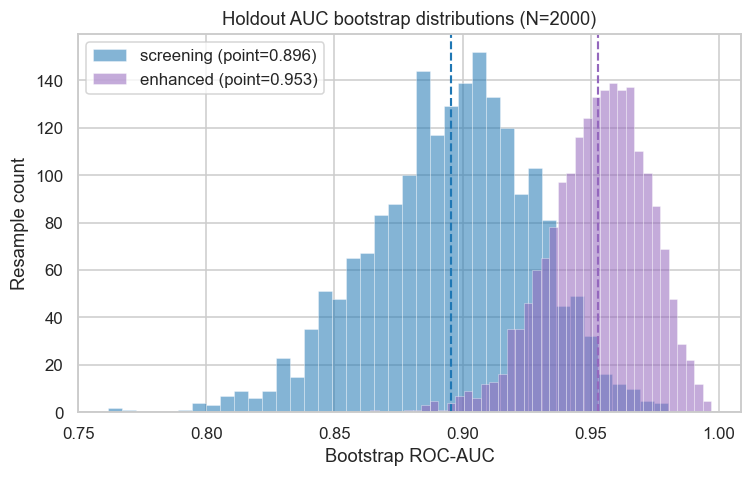

Wrote C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\figures\auc_bootstrap_distribution.png


In [8]:
json_payload = {
    "meta": {
        "random_state": RANDOM_STATE,
        "n_boot": N_BOOT,
        "holdout_n": int(n_holdout),
        "test_size": 0.25,
        "thresholds": {name: float(h["threshold"]) for name, h in holdout.items()},
        "metrics": METRIC_NAMES,
    },
    **summary,
    "auc_difference": auc_difference,
}

json_path = METRICS_DIR / "holdout_bootstrap_cis.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(json_payload, f, indent=2)
print("Wrote", json_path)

csv_path = METRICS_DIR / "holdout_bootstrap_cis.csv"
summary_table.to_csv(csv_path, index=False)
print("Wrote", csv_path)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"screening": "#1f77b4", "enhanced": "#9467bd"}
for name in ["screening", "enhanced"]:
    draws = boot_results[name]["roc_auc"].dropna().to_numpy()
    point = holdout[name]["point_auc"]
    ax.hist(draws, bins=40, alpha=0.55, color=colors[name],
            label=f"{name} (point={point:.3f})", edgecolor="white", linewidth=0.4)
    ax.axvline(point, color=colors[name], linestyle="--", linewidth=1.4)
ax.set_xlabel("Bootstrap ROC-AUC")
ax.set_ylabel("Resample count")
ax.set_title(f"Holdout AUC bootstrap distributions (N={N_BOOT})")
ax.legend(loc="upper left", frameon=True)
fig.tight_layout()
fig_path = FIGURES_DIR / "auc_bootstrap_distribution.png"
fig.savefig(fig_path, dpi=160)
plt.show()
print("Wrote", fig_path)

## Sanity-Check: All Three Output Files Exist


In [9]:
paths_to_check = [
    METRICS_DIR / "holdout_bootstrap_cis.json",
    METRICS_DIR / "holdout_bootstrap_cis.csv",
    FIGURES_DIR / "auc_bootstrap_distribution.png",
]
for p in paths_to_check:
    assert p.exists(), f"Missing output: {p}"
    assert p.stat().st_size > 0, f"Empty output: {p}"
    print(f"OK: {p} ({p.stat().st_size} bytes)")


OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\metrics\holdout_bootstrap_cis.json (3368 bytes)
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\metrics\holdout_bootstrap_cis.csv (1506 bytes)
OK: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a18d5ae6b2abf7485\outputs\figures\auc_bootstrap_distribution.png (65407 bytes)
